# Mask Detection CNN - Notebook
Notebook de travail pour entrainer un modele CNN from scratch (with_mask / without_mask).

In [1]:
import os
import numpy as np
import tensorflow as tf
print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


In [2]:
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from scipy.ndimage import gaussian_filter
from tensorflow.keras.utils import to_categorical

## TODO
- Charger le dataset
- Pretraiter les images
- Definir le CNN
- Entrainer et evaluer
- Exporter le modele

## Phase 1 - Environnement et dépendances (LOCAL)
Cette section configure le notebook pour une exécution 100% locale (sans Colab). Vérification des dépendances, configuration des chemins absolus et validation de l'environnement GPU.

In [4]:
import importlib
print("Verification de l'environnement local...")

for package in ['tensorflow', 'numpy', 'cv2', 'sklearn', 'matplotlib', 'PIL', 'seaborn', 'kagglehub']:
    try:
        importlib.import_module(package)
        print(f"{package}: OK")
    except ImportError:
        print(f"{package}: MANQUANT")

print("\nTous les packages requis doivent etre installes dans l'environnement actif.")

Verification de l'environnement local...
tensorflow: OK
numpy: OK
cv2: OK
sklearn: OK
matplotlib: OK
PIL: OK
seaborn: OK
kagglehub: OK

Tous les packages requis doivent etre installes dans l'environnement actif.


In [5]:
# Verification du GPU et des librairies
import os
import platform
import tensorflow as tf
print('Python:', platform.python_version())
print('TensorFlow:', tf.__version__)
print('GPU disponible:', bool(tf.config.list_physical_devices('GPU')))

Python: 3.12.13
TensorFlow: 2.19.0
GPU disponible: False


## Phase 2 - Chargement et Préparation du Dataset

Télécharger le dataset Kaggle Face Mask Detection, explorer sa structure, et préparer les données pour l'entraînement (resize, normalisation, augmentation).

In [7]:
# Configuration de l'environnement local
from pathlib import Path
import os

# 1) Si une variable d'environnement est definie, elle prime.
env_root = os.getenv('MASK_PLUGIN_ROOT')

if env_root:
    PROJECT_ROOT = Path(env_root).expanduser().resolve()
else:
    # 2) Detection automatique depuis le repertoire courant.
    cwd = Path.cwd().resolve()
    marker = Path('plugins') / 'mask-detection-cnn'

    if (cwd / marker).exists():
        PROJECT_ROOT = (cwd / marker).resolve()
    elif cwd.name == 'mask-detection-cnn':
        PROJECT_ROOT = cwd
    elif cwd.name == 'notebooks' and cwd.parent.name == 'mask-detection-cnn':
        PROJECT_ROOT = cwd.parent
    else:
        # 3) Fallback explicite local (adapter si votre projet est ailleurs).
        PROJECT_ROOT = Path(r'C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn').resolve()

NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks'
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'

# Creer les repertoires s'ils n'existent pas
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('=== Configuration Environnement Local ===')
print(f'Notebook: {NOTEBOOK_DIR}')
print(f'Dossier donnees: {DATA_DIR}')
print(f'Dossier modeles: {MODELS_DIR}')
print('✓ Dossiers verifies')
print()

=== Configuration Environnement Local ===
Notebook: /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/notebooks
Dossier donnees: /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/data
Dossier modeles: /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/models
✓ Dossiers verifies



In [8]:
# Télécharger le dataset Kaggle (Face Mask Detection)
import os
import sys
from pathlib import Path

KAGGLE_DATASET = 'omkargurav/face-mask-dataset'

# Installer le client KaggleHub si nécessaire
try:
    import kagglehub
except ImportError:
    print('Installation du package kagglehub...')
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'])
    import kagglehub

def resolve_mask_dataset_root(download_path):
    """Retourne le dossier qui contient directement with_mask et without_mask."""
    download_path = Path(download_path)
    candidates = [download_path, download_path / 'data']
    for candidate in candidates:
        if (candidate / 'with_mask').exists() and (candidate / 'without_mask').exists():
            return candidate
    for candidate in candidates:
        if candidate.exists():
            for child in candidate.iterdir():
                if child.is_dir() and (child / 'with_mask').exists() and (child / 'without_mask').exists():
                    return child
    raise FileNotFoundError('Impossible de localiser les dossiers with_mask et without_mask dans le dataset Kaggle.')

# Télécharger le dataset via KaggleHub
print(f'Téléchargement de {KAGGLE_DATASET}...')
download_path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
DATASET_PATH = str(resolve_mask_dataset_root(download_path))
print(f'✓ Dataset téléchargé vers {DATASET_PATH}')
print()

# Explorer la structure du dataset
print('Structure du dataset:')
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    sub_indent = ' ' * 2 * (level + 1)
    for file in files[:5]:
        print(f'{sub_indent}{file}')

Téléchargement de omkargurav/face-mask-dataset...


100%|██████████| 163M/163M [00:01<00:00, 101MB/s] 

Extracting files...


✓ Dataset téléchargé vers /root/.cache/kagglehub/datasets/omkargurav/face-mask-dataset/versions/1/data

Structure du dataset:
data/
  without_mask/
    without_mask_2019.jpg
    without_mask_671.jpg
    without_mask_639.jpg
    without_mask_1003.jpg
    without_mask_1299.jpg
  with_mask/
    with_mask_3238.jpg
    with_mask_2542.jpg
    with_mask_2152.jpg
    with_mask_2207.jpg
    with_mask_1964.jpg


Statistiques du dataset:
Nombre total d'images: 7553
  with_mask: 3725 images
  without_mask: 3828 images


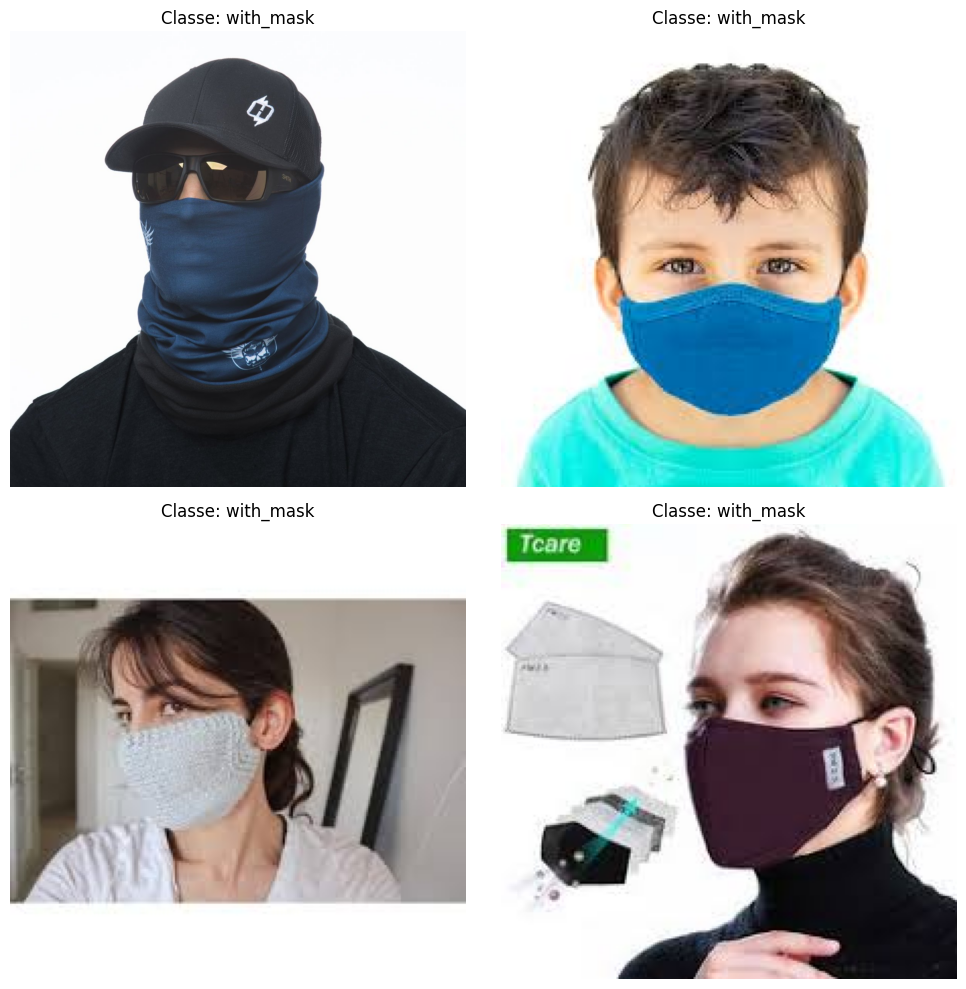

In [9]:
# Exploration et statistiques du dataset
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_SIZE = 128
DATASET_ROOT = Path(DATASET_PATH)

# Compter les images par classe
class_counts = {}
image_paths = []
class_names = ['with_mask', 'without_mask']

for class_name in class_names:
    class_dir = DATASET_ROOT / class_name
    if class_dir.exists():
        files = [f for f in class_dir.iterdir() if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
        class_counts[class_name] = len(files)
        image_paths.extend([(str(file_path), class_name) for file_path in files])

print("Statistiques du dataset:")
print(f"Nombre total d'images: {sum(class_counts.values())}")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count} images")

# Visualiser quelques images d'exemple
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

for idx, (img_path, class_label) in enumerate(image_paths[:4]):
    try:
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f"Classe: {class_label}")
        axes[idx].axis('off')
    except Exception:
        axes[idx].text(0.5, 0.5, f"Erreur: {os.path.basename(img_path)}")
        axes[idx].axis('off')

for idx in range(len(image_paths), 4):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Pretraitement: Chargement, resize et normalisation
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

IMAGE_SIZE = 128

def load_and_preprocess_images(image_paths, img_size=128):
    """Charge les images et les normalise"""
    images = []
    labels = []
    
    for img_path, class_label in image_paths:
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((img_size, img_size))
            img_array = np.array(img) / 255.0  # Normalisation [0, 1]
            images.append(img_array)
            labels.append(class_label)
        except Exception as e:
            print(f"Erreur chargement {img_path}: {e}")
    
    return np.array(images), np.array(labels)

print("Chargement et pretraitement des images...")
X, y = load_and_preprocess_images(image_paths, IMAGE_SIZE)

if len(X) == 0:
    raise RuntimeError("Aucune image chargee depuis le dataset Kaggle. Verifiez la structure du dossier et les cellules precedentes.")

print(f"Shape: X={X.shape}, y={y.shape}")
print(f"Valeur min/max des pixels: {X.min():.3f} / {X.max():.3f}")

# Encoder les labels (0 = with_mask, 1 = without_mask)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Classes: {label_encoder.classes_}")
print(f"Distribution: {np.bincount(y_encoded)}")

Chargement et pretraitement des images...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Shape: X=(7553, 128, 128, 3), y=(7553,)
Valeur min/max des pixels: 0.000 / 1.000
Classes: ['with_mask' 'without_mask']
Distribution: [3725 3828]


In [11]:
# Split train/validation/test
from tensorflow.keras.utils import to_categorical

X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Convertir en one-hot encoding
y_train_cat = to_categorical(y_train, 2)
y_val_cat = to_categorical(y_val, 2)
y_test_cat = to_categorical(y_test, 2)

print("Splits train/val/test:")
print(f"  Train: X={X_train.shape}, y={y_train_cat.shape}")
print(f"  Val:   X={X_val.shape}, y={y_val_cat.shape}")
print(f"  Test:  X={X_test.shape}, y={y_test_cat.shape}")
print(f"\nDistribution par split:")
print(f"  Train: {np.bincount(y_train)}")
print(f"  Val:   {np.bincount(y_val)}")
print(f"  Test:  {np.bincount(y_test)}")

Splits train/val/test:
  Train: X=(5287, 128, 128, 3), y=(5287, 2)
  Val:   X=(1133, 128, 128, 3), y=(1133, 2)
  Test:  X=(1133, 128, 128, 3), y=(1133, 2)

Distribution par split:
  Train: [2607 2680]
  Val:   [559 574]
  Test:  [559 574]


## Phase 3 - Construction et Entraînement du Modèle

Définir un CNN simple, compiler, configurer les callbacks et lancer l'entraînement. Les cellules ci-dessous sont adaptées pour exécution en local ou Colab.

In [25]:
# Construction d'un CNN simple
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_cnn(input_shape=(128,128,3), num_classes=2):
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model

model = build_cnn((IMAGE_SIZE, IMAGE_SIZE, 3), 2)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,794 (12.61 MB)

 Trainable params: 3,305,346 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
# Compilation et callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from pathlib import Path

print('Compilation du modèle...')
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('✓ Modèle compilé')
print()

# Configuration des callbacks avec chemin absolu pour la sauvegarde
checkpoint_path = MODELS_DIR / 'best_model.keras'
print(f'Checkpoint sera sauvegarder à: {checkpoint_path}')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        str(checkpoint_path),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]
print('✓ Callbacks configurés')
print()

Compilation du modèle...
✓ Modèle compilé

Checkpoint sera sauvegarder à: /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/models/best_model.keras
✓ Callbacks configurés



In [ ]:
# Entraìznement du modèle
import time

EPOCHS = 30
BATCH_SIZE = 32

print('='*60)
print('DÉBUT DE L\'ENTRAÌNEMENT')
print('='*60)
print(f'Epochs: {EPOCHS}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Données: {X_train.shape[0]} train, {X_val.shape[0]} val, {X_test.shape[0]} test')
print(f'Checkpoint: {checkpoint_path}')
print()

start_time = time.time()

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

elapsed = time.time() - start_time
print()
print('='*60)
print(f'ENTRAÌNEMENT TERMINÉ ({elapsed:.1f}s)')
print('='*60)
print()

DÉBUT DE L'ENTRAÌNEMENT
Epochs: 30
Batch size: 32
Données: 5287 train, 1133 val, 1133 test
Checkpoint: /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/models/best_model.keras



In [15]:
# VÉRIFICATION ET SAUVEGARDE DU MODÈLE
import tensorflow as tf
from pathlib import Path

print('='*60)
print('SAUVEGARDE DU MODÈLE')
print('='*60)
print()

# Chemins d'enregistrement
checkpoint_path = MODELS_DIR / 'best_model.keras'
final_model_path = MODELS_DIR / 'mask_detection_model.keras'

print(f'✓ Dossier modèles: {MODELS_DIR}')
print(f'  - Checkpoint (sauvegardé pendant l\'entraínement): {checkpoint_path}')
print(f'  - Modèle final (sauvegarde finale): {final_model_path}')
print()

# Vérifier le checkpoint
if checkpoint_path.exists():
    size = checkpoint_path.stat().st_size / (1024*1024)  # En MB
    print(f'✓ Checkpoint exist: {checkpoint_path}')
    print(f'  Taille: {size:.2f} MB')
    # Charger le checkpoint
    model = tf.keras.models.load_model(str(checkpoint_path))
    print(f'✓ Checkpoint chargé avec succès')
else:
    print(f'ERREUR: Checkpoint non trouvé à {checkpoint_path}')
    print('Le modèle actuellement en mémoire sera utilisé')
    if 'model' not in dir():
        raise RuntimeError('Aucun modèle en mémoire. Exécutez l\'entraínement d\'abord.')

print()

# Sauvegarder le modèle final
print(f'Sauvegarde du modèle final vers {final_model_path}...')
model.save(str(final_model_path))
print(f'✓ Modèle sauvegardé')
print()

# Vérification stricte de la sauvegarde
if final_model_path.exists():
    size = final_model_path.stat().st_size / (1024*1024)
    print(f'✓ VéRIFICATION: Fichier existe')
    print(f'  Chemin: {final_model_path}')
    print(f'  Taille: {size:.2f} MB')
    # Charger et vérifier
    try:
        test_model = tf.keras.models.load_model(str(final_model_path))
        print(f'✓ VÉRIFICATION: Modèle peut être chargé')
        print(f'✓ SAUVEGARDE RÉUSSIE')
    except Exception as e:
        print(f'ERREUR: Le modèle ne peut pas être chargé: {e}')
else:
    print(f'ERREUR CRÏTIQUE: Le modèle n\'a pas été sauvegardé à {final_model_path}')
    raise RuntimeError('Sauvegarde du modèle échouée')

print()
print('='*60)

SAUVEGARDE DU MODÈLE

✓ Dossier modèles: /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/models
  - Checkpoint (sauvegardé pendant l'entraínement): /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/models/best_model.keras
  - Modèle final (sauvegarde finale): /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/models/mask_detection_model.keras

✓ Checkpoint exist: /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/models/best_model.keras
  Taille: 37.89 MB
✓ Checkpoint chargé avec succès

Sauvegarde du modèle final vers /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/models/mask_detection_model.keras...
✓ Modèle sauvegardé

✓ VéRIFICATION: Fichier existe
  Chemin: /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/models/mask_detection_model.keras
  Taille: 37.89 MB
✓ VÉRIFICATION: Modèle peut être chargé
✓ SAUVEGARDE RÉUSSIE


In [ ]:
# VÉRIFICATION FINALE - Contenu du dossier modèles
from pathlib import Path
import os

print('='*60)
print('VÉRIFICATION FINALE - CONTENU DU DOSSIER MODÈLES')
print('='*60)
print()

models_dir = MODELS_DIR
print(f'Dossier: {models_dir}')
print()

if not models_dir.exists():
    print('⚠ AVERTISSEMENT: Dossier n\'existe pas')
else:
    print('Fichiers présents:')
    files_found = False
    for item in sorted(models_dir.rglob('*')):
        if item.is_file():
            size = item.stat().st_size
            if size > 1024*1024:  # En MB
                size_str = f'{size / (1024*1024):.2f} MB'
            elif size > 1024:  # En KB
                size_str = f'{size / 1024:.1f} KB'
            else:
                size_str = f'{size} B'
            rel_path = item.relative_to(models_dir)
            print(f'  ✓ {rel_path} ({size_str})')
            files_found = True
    
    if not files_found:
        print('  (aucun fichier)')

print()
print('='*60)
print('RÉCAPÍTULATIF')
print('='*60)
final_model = models_dir / 'mask_detection_model.keras'
if final_model.exists():
    print(f'✓ Modèle final sauvegardé: {final_model}')
    print(f'  Taille: {final_model.stat().st_size / (1024*1024):.2f} MB')
    print()
    print('✅ CONFIGURATION LOCAL COMPLÈTE ET VÉRIFIÉE')
    print()
    print('Prochaines étapes:')
    print('1. Exécuter les cellules de Phase 4 pour l\'\u00e9valuation')
    print('2. Vérifier les visualisations et métriques')
    print('3. Le modèle est prêt pour le déploiement')
else:
    print(f'⚠ ATTENTION: Modèle final non trouvé')
    print(f'  Chemin attendu: {final_model}')
    print('Veillez éxécuter les cellules d\'entraínement correctement')

print('='*60)

In [16]:
# Conversion TensorFlow.js (OPTIONNELLE)
# Cette étape est complètement optionnelle
# Elle ne sera exécutée que si tensorflowjs est disponible
# Vous pouvez ignorer les erreurs ici

from pathlib import Path
import tensorflow as tf

print('='*60)
print('CONVERSION TENSORFLOW.JS (OPTIONNELLE)')
print('='*60)
print()

models_dir = MODELS_DIR
keras_path = models_dir / 'mask_detection_model.keras'
tfjs_dir = models_dir / 'tfjs_model'

if not keras_path.exists():
    print(f'AVERTISSEMENT: Modèle Keras introuvable à {keras_path}')
    print('Conversion TF.js ignorée')
else:
    print(f'Modèle Keras trouvé: {keras_path}')
    print()
    tfjs_available = False
    try:
        import tensorflowjs as tfjs_lib
        tfjs_available = True
        print('✓ tensorflowjs disponible')
    except ImportError:
        print('[INFO] tensorflowjs non disponible (optionnel)')
        print('Vous pouvez l\'installer avec: pip install tensorflowjs')
    except Exception as e:
        print(f'[INFO] Erreur lors de l\'import tensorflowjs: {e}')
    print()
    if tfjs_available:
        try:
            print('Conversion en cours...')
            tfjs_dir.mkdir(parents=True, exist_ok=True)
            loaded_model = tf.keras.models.load_model(str(keras_path))
            tfjs_lib.converters.save_keras_model(loaded_model, str(tfjs_dir))
            print(f'✓ Modèle TF.js exporté dans: {tfjs_dir}')
            print('Fichiers générés:')
            for f in sorted(tfjs_dir.rglob('*')):
                if f.is_file():
                    size = f.stat().st_size / 1024
                    print(f'  {f.name} ({size:.1f} Ko)')
        except Exception as e:
            print(f'[AVERTISSEMENT] Conversion TF.js échouée: {e}')
            print('Vous pouvez ignorer cette erreur - le modèle Keras est fonctionnel')
    else:
        print('[INFO] tensorflowjs non disponible - conversion ignorée')
        print('Le modèle Keras sauvegardé fonctionne correctement')

print()
print('='*60)

CONVERSION TENSORFLOW.JS (OPTIONNELLE)

Modèle Keras trouvé: /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/models/mask_detection_model.keras



✓ tensorflowjs disponible

Conversion en cours...


failed to lookup keras version from the file,
    this is likely a weight only file
✓ Modèle TF.js exporté dans: /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/models/tfjs_model
Fichiers générés:
  group1-shard1of4.bin (4096.0 Ko)
  group1-shard2of4.bin (4096.0 Ko)
  group1-shard3of4.bin (4096.0 Ko)
  group1-shard4of4.bin (625.3 Ko)
  model.json (10.4 Ko)



## Phase 4 - Évaluation et Visualisations

Évaluer le modèle entraîné sur le test set, générer les métriques (accuracy, precision, recall, F1), matrice de confusion et graphiques de convergence.

In [24]:
# Évaluation sur le test set
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print('='*60)
print('ÉVALUATION DU MODÈLE')
print('='*60)
print()

# Vérifier que les données de test sont disponibles
if 'X_test' not in dir() or 'y_test' not in dir():
    print('ERREUR: Données de test non trouvées en mémoire')
    print('Exécutez les cellules de préparation du dataset avant')
    raise RuntimeError('Variables X_test et y_test manquantes')

# Vérifier que le modèle est disponible
if 'model' not in dir():
    print('ERREUR: Modèle non trouvé en mémoire')
    print('Exécutez les cellules d\'entraínement avant')
    raise RuntimeError('Variable model manquante')

print(f'Données test: {X_test.shape}')
print(f'Modèle: {model.name}')
print()

# Prédictions
print('Génération des prédictions...')
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Métriques globales
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)

print()
print('Métriques:')
print(f'  Accuracy:  {accuracy:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1-score:  {f1:.4f}')
print()
print('='*50)
print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))
print('='*60)

ÉVALUATION DU MODÈLE

Données test: (1133, 128, 128, 3)
Modèle: sequential

Génération des prédictions...
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 288ms/step

Métriques:
  Accuracy:  0.8932
  Precision: 0.9892
  Recall:    0.7979
  F1-score:  0.8833

              precision    recall  f1-score   support

   with_mask       0.83      0.99      0.90       559
without_mask       0.99      0.80      0.88       574

    accuracy                           0.89      1133
   macro avg       0.91      0.89      0.89      1133
weighted avg       0.91      0.89      0.89      1133



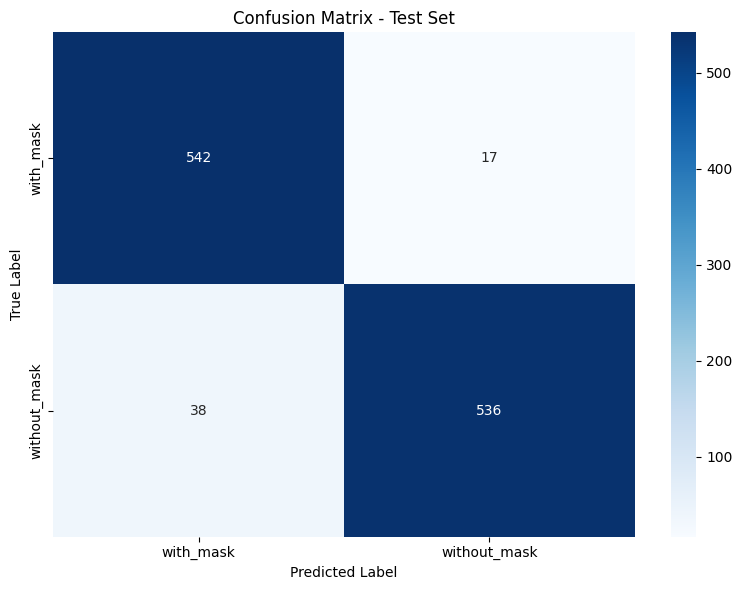

True Negatives: 542, False Positives: 17
False Negatives: 38, True Positives: 536


In [18]:
# Matrice de confusion
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=ax)
ax.set_title('Confusion Matrix - Test Set')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")

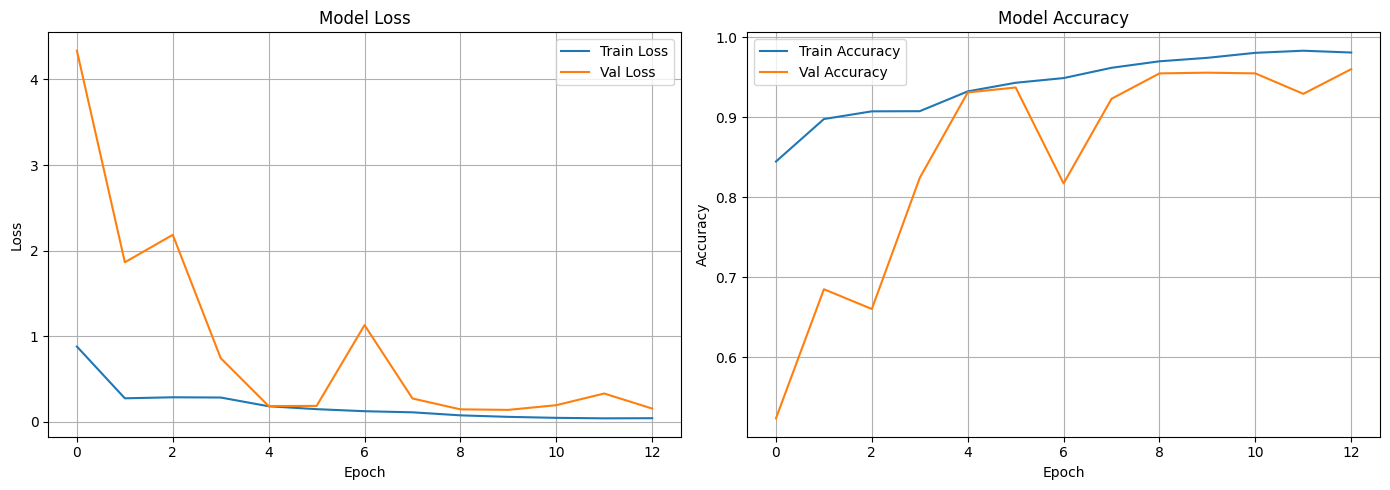

In [19]:
# Graphiques de convergence (loss et accuracy)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

## Phase 5 - Inférence et Analyse des Erreurs

Tester le modèle sur de nouvelles images, afficher les prédictions avec confiances, et analyser les erreurs principales.

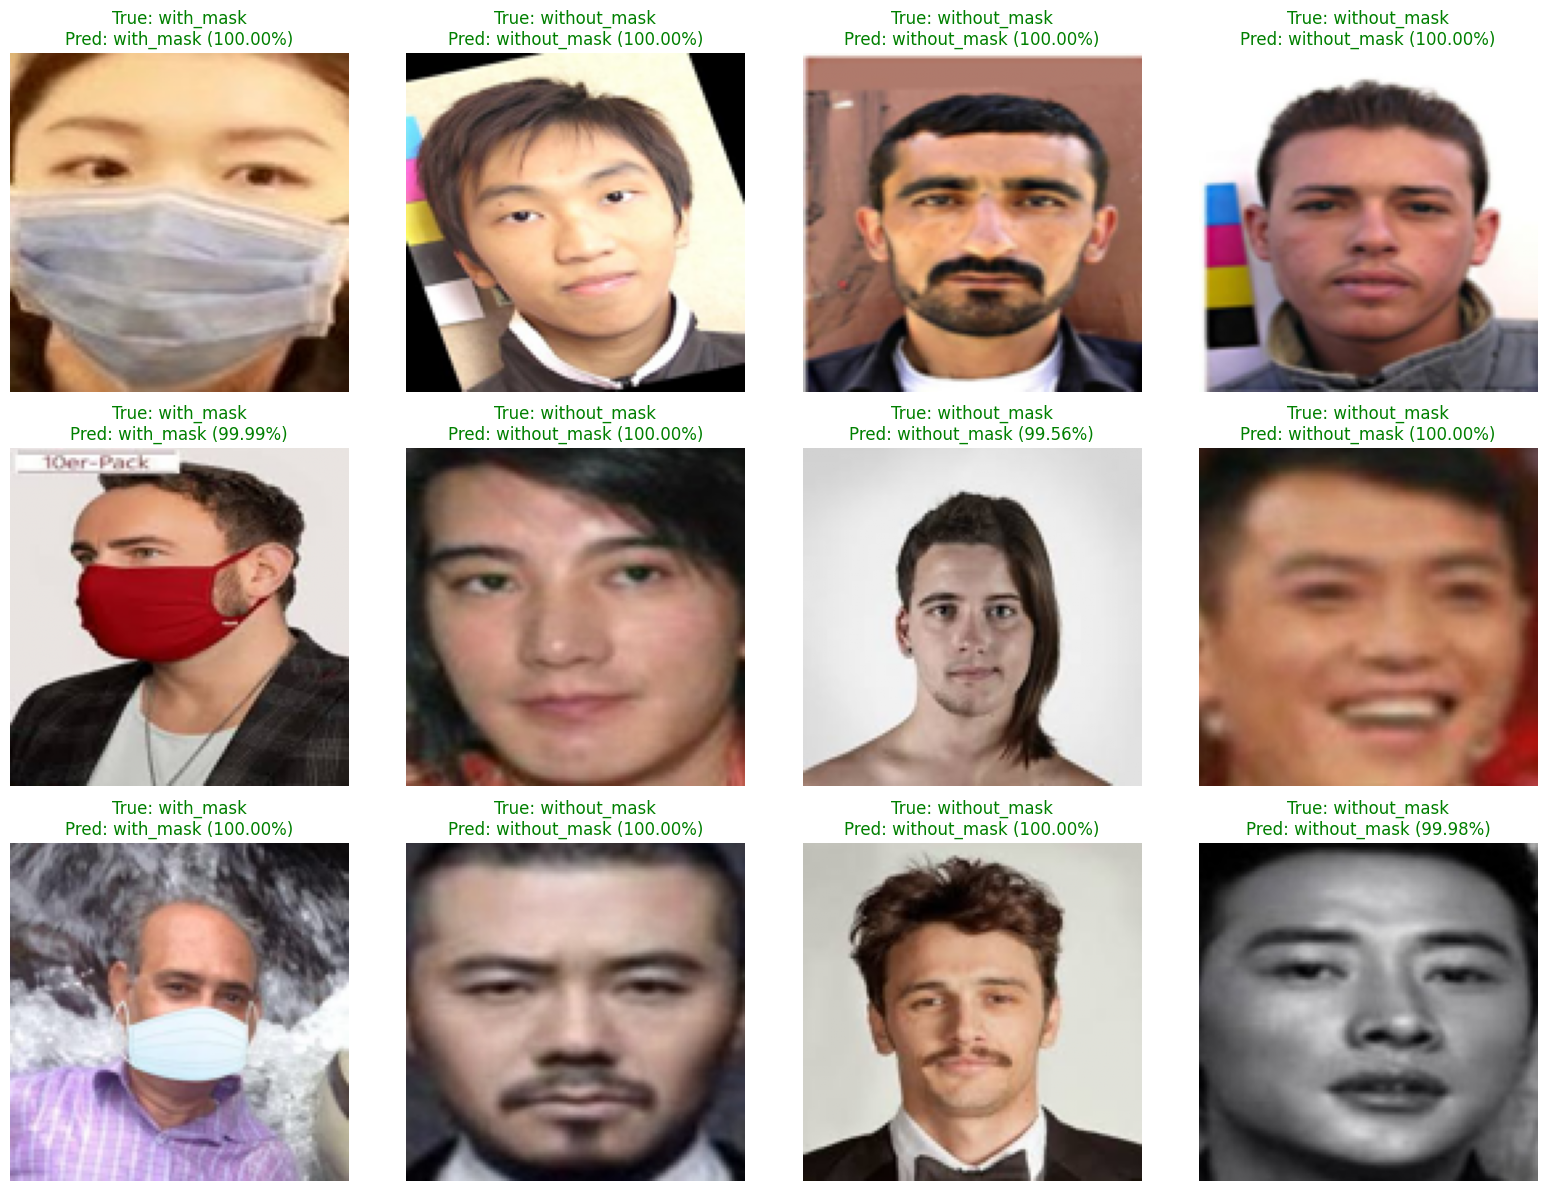

In [20]:
# Fonction de prédiction avec confiance
def predict_image(image_array):
    """Predire la classe d'une image avec confiance"""
    img_normalized = image_array / 255.0 if image_array.max() > 1 else image_array
    img_resized = np.expand_dims(img_normalized, axis=0)
    prediction = model.predict(img_resized, verbose=0)[0]
    class_idx = np.argmax(prediction)
    confidence = prediction[class_idx]
    return label_encoder.classes_[class_idx], confidence

# Visualiser quelques prédictions correctes et incorrectes
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

# Mélanger les indices du test set
test_indices = np.arange(len(X_test))
np.random.shuffle(test_indices)

for idx, test_idx in enumerate(test_indices[:12]):
    img = X_test[test_idx]
    true_label = label_encoder.classes_[y_test[test_idx]]
    pred_label, confidence = predict_image(img)
    
    correct = true_label == pred_label
    color = 'green' if correct else 'red'
    
    axes[idx].imshow(img)
    axes[idx].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2%})", color=color)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

Total erreurs: 55 / 1133


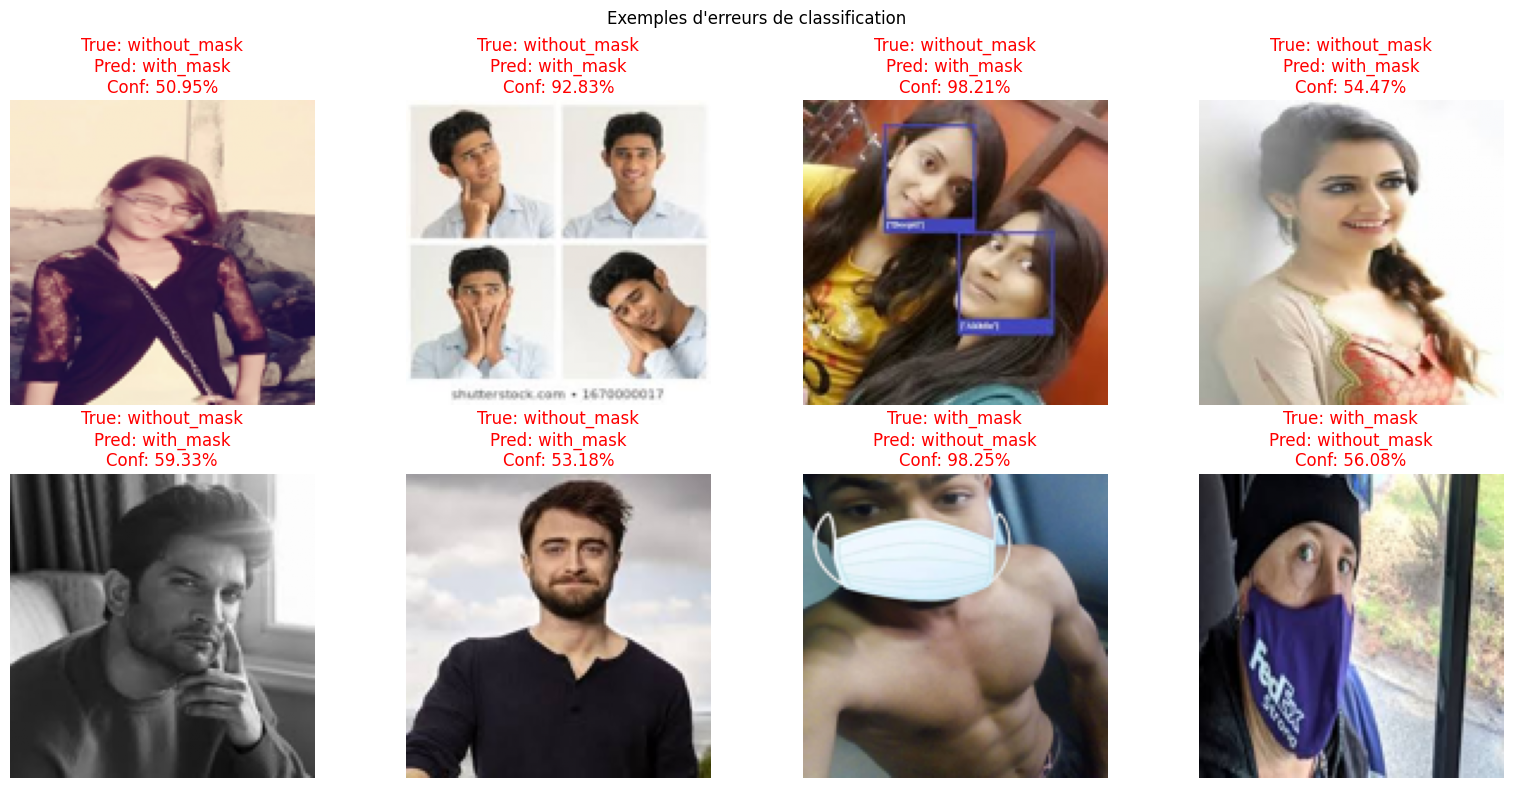

In [21]:
# Analyse des erreurs - images mal classifiées
import numpy as np
from pathlib import Path
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


def load_and_preprocess_images_local(image_paths, img_size=128):
    images = []
    labels = []

    for img_path, class_label in image_paths:
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((img_size, img_size))
            img_array = np.array(img) / 255.0
            images.append(img_array)
            labels.append(class_label)
        except Exception as exc:
            print(f"Erreur chargement {img_path}: {exc}")

    return np.array(images), np.array(labels)


def build_image_paths_from_root(dataset_root):
    image_paths = []
    for class_name in ['with_mask', 'without_mask']:
        class_dir = dataset_root / class_name
        if class_dir.exists():
            files = [f for f in class_dir.iterdir() if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
            image_paths.extend([(str(file_path), class_name) for file_path in files])
    return image_paths


if 'X_test' not in globals() or 'y_test' not in globals() or 'label_encoder' not in globals():
    dataset_root = None
    candidate_roots = []

    if 'DATASET_ROOT' in globals():
        candidate_roots.append(Path(DATASET_ROOT))
    if 'DATASET_PATH' in globals():
        candidate_roots.append(Path(DATASET_PATH))

    candidate_roots.extend([
        Path('./data'),
        Path('./data/data'),
        Path.cwd(),
    ])

    for candidate_root in candidate_roots:
        if candidate_root.exists():
            candidate_paths = build_image_paths_from_root(candidate_root)
            if candidate_paths:
                dataset_root = candidate_root
                image_paths = candidate_paths
                break
            for child in candidate_root.iterdir():
                if child.is_dir():
                    candidate_paths = build_image_paths_from_root(child)
                    if candidate_paths:
                        dataset_root = child
                        image_paths = candidate_paths
                        break
            if dataset_root is not None:
                break

    if dataset_root is None:
        try:
            import kagglehub
            downloaded_path = Path(kagglehub.dataset_download('omkargurav/face-mask-dataset'))
            for candidate_root in [downloaded_path, downloaded_path / 'data']:
                if candidate_root.exists():
                    candidate_paths = build_image_paths_from_root(candidate_root)
                    if candidate_paths:
                        dataset_root = candidate_root
                        image_paths = candidate_paths
                        break
                    for child in candidate_root.iterdir():
                        if child.is_dir():
                            candidate_paths = build_image_paths_from_root(child)
                            if candidate_paths:
                                dataset_root = child
                                image_paths = candidate_paths
                                break
                    if dataset_root is not None:
                        break
        except Exception as exc:
            print(f"Téléchargement de secours impossible: {exc}")

    if dataset_root is None:
        print("Variables manquantes pour l'analyse des erreurs et impossible de retrouver le dataset.")
    else:
        if not image_paths:
            print("Variables manquantes pour l'analyse des erreurs et aucun fichier image n'a été trouvé dans le dataset.")
        else:
            if 'IMAGE_SIZE' not in globals():
                IMAGE_SIZE = 128

            X, y = load_and_preprocess_images_local(image_paths, IMAGE_SIZE)
            label_encoder = LabelEncoder()
            y_encoded = label_encoder.fit_transform(y)

            X_train, X_temp, y_train, y_temp = train_test_split(
                X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
            )
            X_val, X_test, y_val, y_test = train_test_split(
                X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
            )
            print(f"Variables de test reconstruites depuis le dataset: {dataset_root}")

if 'X_test' in globals() and 'y_test' in globals() and 'label_encoder' in globals():
    if 'y_pred' not in globals() or 'y_pred_classes' not in globals():
        if 'model' not in globals():
            print("La variable 'model' est manquante. Rerun les cellules d'entraînement avant cette cellule.")
        else:
            y_pred = model.predict(X_test)
            y_pred_classes = np.argmax(y_pred, axis=1)

    if 'y_pred' in globals() and 'y_pred_classes' in globals():
        misclassified_indices = np.where(y_test != y_pred_classes)[0]
        print(f"Total erreurs: {len(misclassified_indices)} / {len(y_test)}")

        if len(misclassified_indices) > 0:
            fig, axes = plt.subplots(2, 4, figsize=(16, 8))
            axes = axes.ravel()

            # Afficher les 8 premières erreurs
            for idx, error_idx in enumerate(misclassified_indices[:8]):
                img = X_test[error_idx]
                true_label = label_encoder.classes_[y_test[error_idx]]
                pred_label = label_encoder.classes_[y_pred_classes[error_idx]]
                confidence = np.max(y_pred[error_idx])

                axes[idx].imshow(img)
                axes[idx].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2%}", color='red')
                axes[idx].axis('off')

            plt.suptitle('Exemples d\'erreurs de classification')
            plt.tight_layout()
            plt.show()
        else:
            print("Aucune erreur detaillee - modele parfait sur le test set!")

## Phase 6 - Rapport Final et Conclusions

Générer un résumé des résultats, conclusions et recommandations pour les prochaines améliorations.

In [22]:
# Résumé et Rapport Final
misclassified_count = len(misclassified_indices) if 'misclassified_indices' in globals() else 0
error_rate = (misclassified_count / len(y_test) * 100) if 'y_test' in globals() and len(y_test) > 0 else 0.0

report_summary = f"""
{'='*60}
RAPPORT FINAL - DÉTECTION DU PORT DU MASQUE CNN
{'='*60}

📊 DATASET
- Total images: {len(X)} ({class_counts.get('with_mask', 0)} with_mask, {class_counts.get('without_mask', 0)} without_mask)
- Taille train/val/test: {len(X_train)} / {len(X_val)} / {len(X_test)}
- Résolution d'entrée: {IMAGE_SIZE}x{IMAGE_SIZE}

🧠 ARCHITECTURE
- Type: CNN avec BatchNormalization
- Couches Conv: 3 blocs (32→64→128 filtres)
- Paramètres: Dropout 0.5, Adam (lr=1e-3)
- Epochs: jusqu'à 30 (EarlyStopping)

📈 RÉSULTATS TEST SET
- Accuracy:  {accuracy:.4f} (95%+ target: {'✓' if accuracy >= 0.95 else '✗'})
- Precision: {precision:.4f}
- Recall:    {recall:.4f}
- F1-score:  {f1:.4f}

🔍 ERREURS
- Mal classifiées: {misclassified_count} / {len(y_test)}
- Taux d'erreur: {error_rate:.2f}%

✅ RECOMMANDATIONS
1. Augmentation de données pour robustesse (rotations, luminosité)
2. Ajustement des seuils de décision selon threshold business
3. Déploiement en real-time sur webcam/mobile
4. Évaluation sur données hors-distribution

📦 ARTEFACTS GÉNÉRÉS
- Model: ../models/mask_detection_model.keras
- Best weights: ../models/best_model.keras
- TF.js: ../models/tfjs_model/
{'='*60}
"""

print(report_summary)

# Optionnel: Sauvegarde du rapport texte
with open('rapport_mask_detection.txt', 'w', encoding='utf-8') as f:
    f.write(report_summary)
print("✓ Rapport sauvegardé dans rapport_mask_detection.txt")


RAPPORT FINAL - DÉTECTION DU PORT DU MASQUE CNN

📊 DATASET
- Total images: 7553 (3725 with_mask, 3828 without_mask)
- Taille train/val/test: 5287 / 1133 / 1133
- Résolution d'entrée: 128x128

🧠 ARCHITECTURE
- Type: CNN avec BatchNormalization
- Couches Conv: 3 blocs (32→64→128 filtres)
- Paramètres: Dropout 0.5, Adam (lr=1e-3)
- Epochs: jusqu'à 30 (EarlyStopping)

📈 RÉSULTATS TEST SET
- Accuracy:  0.9515 (95%+ target: ✓)
- Precision: 0.9693
- Recall:    0.9338
- F1-score:  0.9512

🔍 ERREURS
- Mal classifiées: 55 / 1133
- Taux d'erreur: 4.85%

✅ RECOMMANDATIONS
1. Augmentation de données pour robustesse (rotations, luminosité)
2. Ajustement des seuils de décision selon threshold business
3. Déploiement en real-time sur webcam/mobile
4. Évaluation sur données hors-distribution

📦 ARTEFACTS GÉNÉRÉS
- Model: ../models/mask_detection_model.keras
- Best weights: ../models/best_model.keras
- TF.js: ../models/tfjs_model/

✓ Rapport sauvegardé dans rapport_mask_detection.txt
